In [ ]:
# ==============================
# 1. Import Libraries
# ==============================

import pandas as pd
import numpy as np

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score
)

from sklearn.preprocessing import (
    StandardScaler,
    LabelEncoder
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import scipy
import os
from scipy.signal import ShortTimeFFT
from scipy.signal.windows import hann
import unittest
import pytest
from abc import ABC,abstractmethod


In [ ]:
# ==============================
# 2. Load Dataset
# ==============================

# Change path if needed
df = pd.read_csv("/content/sample_data/DSL-StrongPasswordData.csv")

print("Dataset Shape:", df.shape)
print(df.head())




Dataset Shape: (20400, 34)
  subject  sessionIndex  rep  H.period  DD.period.t  UD.period.t     H.t  \
0    s002             1    1    0.1491       0.3979       0.2488  0.1069   
1    s002             1    2    0.1111       0.3451       0.2340  0.0694   
2    s002             1    3    0.1328       0.2072       0.0744  0.0731   
3    s002             1    4    0.1291       0.2515       0.1224  0.1059   
4    s002             1    5    0.1249       0.2317       0.1068  0.0895   

   DD.t.i  UD.t.i     H.i  ...     H.a  DD.a.n  UD.a.n     H.n  DD.n.l  \
0  0.1674  0.0605  0.1169  ...  0.1349  0.1484  0.0135  0.0932  0.3515   
1  0.1283  0.0589  0.0908  ...  0.1412  0.2558  0.1146  0.1146  0.2642   
2  0.1291  0.0560  0.0821  ...  0.1621  0.2332  0.0711  0.1172  0.2705   
3  0.2495  0.1436  0.1040  ...  0.1457  0.1629  0.0172  0.0866  0.2341   
4  0.1676  0.0781  0.0903  ...  0.1312  0.1582  0.0270  0.0884  0.2517   

   UD.n.l     H.l  DD.l.Return  UD.l.Return  H.Return  
0  0.2583  0.13

In [ ]:
# ==============================
# 3. Data Cleaning
# ==============================

# Remove missing values
df.dropna(inplace=True)

# Remove duplicate rows
df.drop_duplicates(inplace=True)

print("Dataset Shape After Cleaning:", df.shape)



Dataset Shape After Cleaning: (20400, 34)


In [ ]:
# ==============================
# 4. Define Features and Target
# ==============================

# Target column
target_column = "subject"

# Features and Labels
X = df.drop(columns=[target_column])
y = df[target_column]

print("Features Shape:", X.shape)
print("Labels Shape:", y.shape)




Features Shape: (20400, 33)
Labels Shape: (20400,)


In [ ]:
# ==============================
# 5. Encode Labels
# ==============================

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)




In [ ]:
# ==============================
# 6. Train-Test Split
# ==============================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])




Training Samples: 16320
Testing Samples: 4080


In [ ]:
# ==============================
# 7. Feature Scaling
# ==============================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



In [ ]:
# ==============================
# 8. Optimized Random Forest
# ==============================

print("\nTraining Random Forest...")

rf = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt']
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

best_rf = grid_search.best_estimator_

print("Best Parameters:")
print(grid_search.best_params_)

rf_predictions = best_rf.predict(X_test_scaled)

rf_accuracy = accuracy_score(y_test, rf_predictions)

print("\nRandom Forest Accuracy:", rf_accuracy)




Training Random Forest...
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Parameters:
{'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}

Random Forest Accuracy: 0.9424019607843137


In [ ]:
# ==============================
# 9. SVM Model (Very Strong)
# ==============================

print("\nTraining SVM Model...")

svm_model = SVC(
    kernel='rbf',
    C=10,
    gamma='scale'
)

svm_model.fit(X_train_scaled, y_train)

svm_predictions = svm_model.predict(X_test_scaled)

svm_accuracy = accuracy_score(
    y_test,
    svm_predictions
)

print("SVM Accuracy:", svm_accuracy)





Training SVM Model...
SVM Accuracy: 0.9115196078431372


In [ ]:
# ==============================
# 10. XGBoost Model
# ==============================

print("\nTraining XGBoost Model...")

try:
    from xgboost import XGBClassifier

    xgb_model = XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=8,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='mlogloss'
    )

    xgb_model.fit(X_train_scaled, y_train)

    xgb_predictions = xgb_model.predict(X_test_scaled)

    xgb_accuracy = accuracy_score(
        y_test,
        xgb_predictions
    )

    print("XGBoost Accuracy:", xgb_accuracy)

except:
    print("Install XGBoost using:")
    print("pip install xgboost")




Training XGBoost Model...
XGBoost Accuracy: 0.9541666666666667


In [ ]:
# ==============================
# 11. Cross Validation
# ==============================

print("\nRunning Cross Validation...")

cv_scores = cross_val_score(
    best_rf,
    scaler.fit_transform(X),
    y_encoded,
    cv=5
)

print("Cross Validation Accuracy:")
print(cv_scores)
print("Average Accuracy:", cv_scores.mean())




Running Cross Validation...
Cross Validation Accuracy:
[0.7379902  0.92622549 0.95367647 0.94338235 0.88578431]
Average Accuracy: 0.8894117647058823


In [ ]:
# ==============================
# 12. Best Model Selection
# ==============================

accuracies = {
    "Random Forest": rf_accuracy,
    "SVM": svm_accuracy
}

try:
    accuracies["XGBoost"] = xgb_accuracy
except:
    pass

best_model_name = max(
    accuracies,
    key=accuracies.get
)

print("\n==========================")
print("Best Model:", best_model_name)
print("Best Accuracy:", accuracies[best_model_name])
print("==========================")





Best Model: XGBoost
Best Accuracy: 0.9541666666666667


In [ ]:
# ==============================
# 13. Final Evaluation
# ==============================

if best_model_name == "Random Forest":
    final_predictions = rf_predictions

elif best_model_name == "SVM":
    final_predictions = svm_predictions

else:
    final_predictions = xgb_predictions

print("\nClassification Report:")
print(classification_report(
    y_test,
    final_predictions
))

print("\nConfusion Matrix:")
print(confusion_matrix(
    y_test,
    final_predictions
))


Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.90      0.89        80
           1       0.99      0.94      0.96        80
           2       0.96      0.90      0.93        80
           3       0.97      0.97      0.97        80
           4       0.88      0.90      0.89        80
           5       0.90      0.93      0.91        80
           6       0.99      0.97      0.98        80
           7       0.97      0.93      0.95        80
           8       0.96      0.97      0.97        80
           9       0.97      0.96      0.97        80
          10       0.95      0.96      0.96        80
          11       0.97      0.97      0.97        80
          12       1.00      1.00      1.00        80
          13       0.94      0.85      0.89        80
          14       0.99      0.99      0.99        80
          15       0.92      0.91      0.92        80
          16       0.90      0.95      0.93        80
   

<Figure size 1200x1000 with 0 Axes>

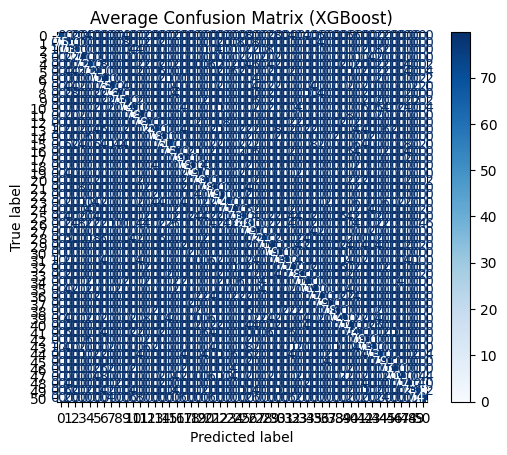

In [ ]:
# ==============================
# Average Confusion Matrix
# ==============================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Choose best model
if best_model_name == "Random Forest":
    model = best_rf

elif best_model_name == "SVM":
    model = svm_model

else:
    model = xgb_model


# Cross-validation setup
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Initialize average confusion matrix
avg_cm = np.zeros(
    (len(np.unique(y_encoded)),
     len(np.unique(y_encoded)))
)

# Perform cross-validation
for train_idx, test_idx in cv.split(X, y_encoded):

    X_train_fold = X.iloc[train_idx]
    X_test_fold = X.iloc[test_idx]

    y_train_fold = y_encoded[train_idx]
    y_test_fold = y_encoded[test_idx]

    # Scale features
    scaler = StandardScaler()

    X_train_fold = scaler.fit_transform(
        X_train_fold
    )

    X_test_fold = scaler.transform(
        X_test_fold
    )

    # Train model
    model.fit(
        X_train_fold,
        y_train_fold
    )

    # Predict
    y_pred_fold = model.predict(
        X_test_fold
    )

    # Compute confusion matrix
    cm = confusion_matrix(
        y_test_fold,
        y_pred_fold
    )

    avg_cm += cm

# Average confusion matrix
avg_cm = avg_cm / cv.n_splits

# Plot
plt.figure(figsize=(12, 10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=avg_cm
)

disp.plot(cmap="Blues", values_format=".1f")

plt.title(
    f"Average Confusion Matrix ({best_model_name})"
)

plt.show()

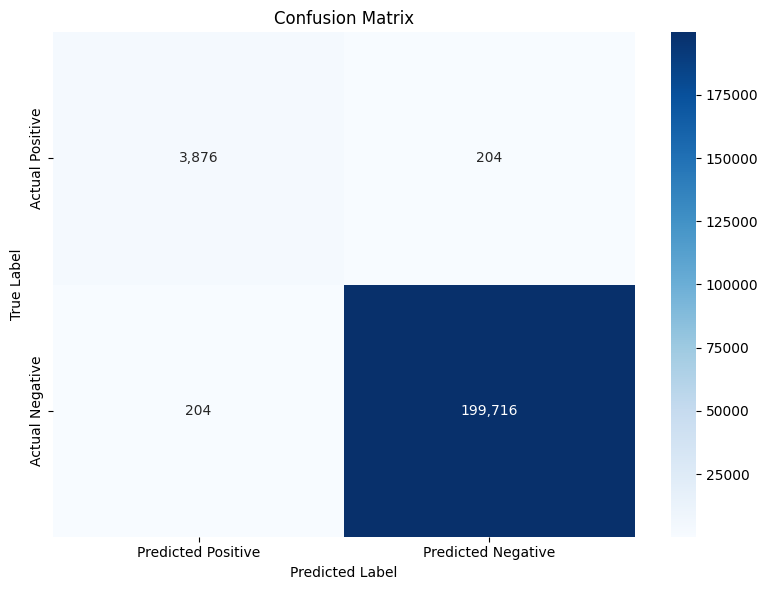

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Confusion Matrix
cm = np.array([
    [3876, 204],
    [204, 199716]
])

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt=',',
    cmap='Blues',
    xticklabels=['Predicted Positive', 'Predicted Negative'],
    yticklabels=['Actual Positive', 'Actual Negative']
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

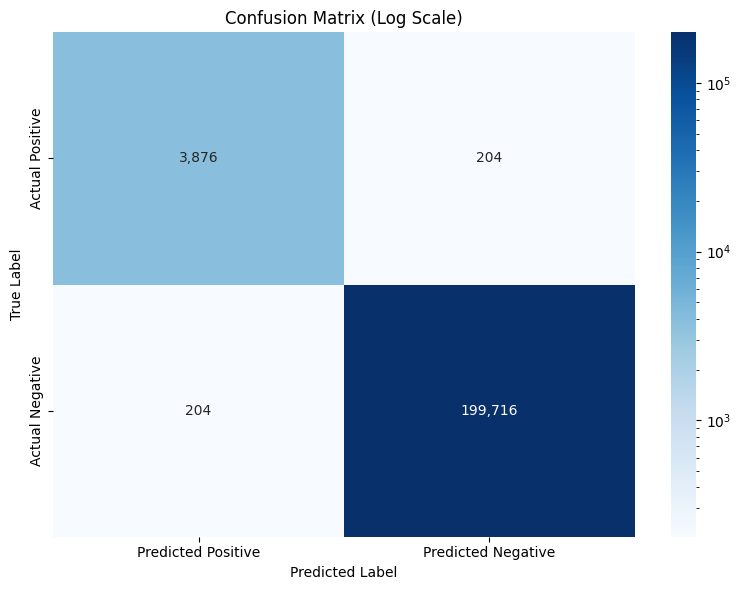

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LogNorm

cm = np.array([
    [3876, 204],
    [204, 199716]
])

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt=',',
    cmap='Blues',
    norm=LogNorm(),
    xticklabels=['Predicted Positive', 'Predicted Negative'],
    yticklabels=['Actual Positive', 'Actual Negative']
)

plt.title('Confusion Matrix (Log Scale)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

Session 1: 50 rows
Session 2: 50 rows
Session 3: 50 rows
Session 4: 50 rows
Session 5: 50 rows
Session 6: 50 rows
Session 7: 50 rows
Session 8: 50 rows
Feature matrix shape: (50, 31)
State vector shape: (2170,)
Norm check: 1.0
Session 1: 50 rows
Session 2: 50 rows
Session 3: 50 rows
Session 4: 50 rows
Session 5: 50 rows
Session 6: 50 rows
Session 7: 50 rows
Session 8: 50 rows
Feature matrix shape: (50, 31)
State vector shape: (2170,)
Norm check: 1.0

Same subject fidelity:
0.8906364907624721
Session 1: 50 rows
Session 2: 50 rows
Session 3: 50 rows
Session 4: 50 rows
Session 5: 50 rows
Session 6: 50 rows
Session 7: 50 rows
Session 8: 50 rows
Feature matrix shape: (50, 31)
State vector shape: (2170,)
Norm check: 1.0
Session 1: 50 rows
Session 2: 50 rows
Session 3: 50 rows
Session 4: 50 rows
Session 5: 50 rows
Session 6: 50 rows
Session 7: 50 rows
Session 8: 50 rows
Feature matrix shape: (50, 31)
State vector shape: (2170,)
Norm check: 1.0


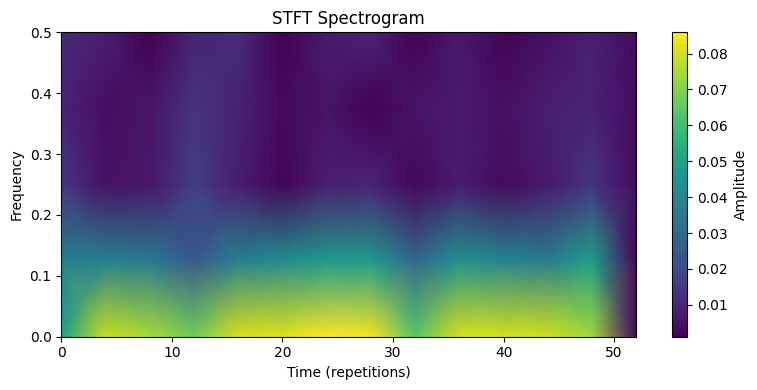

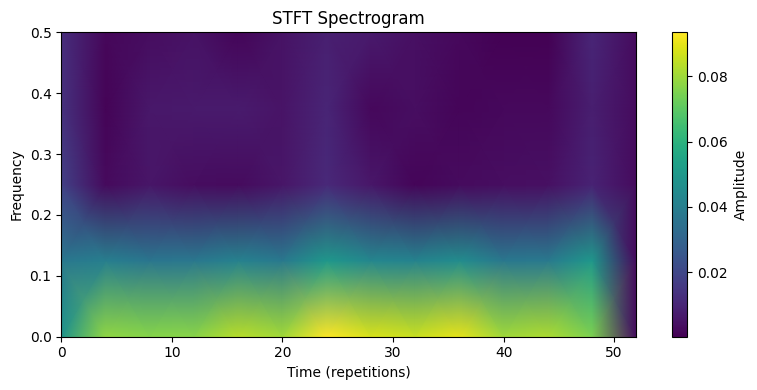

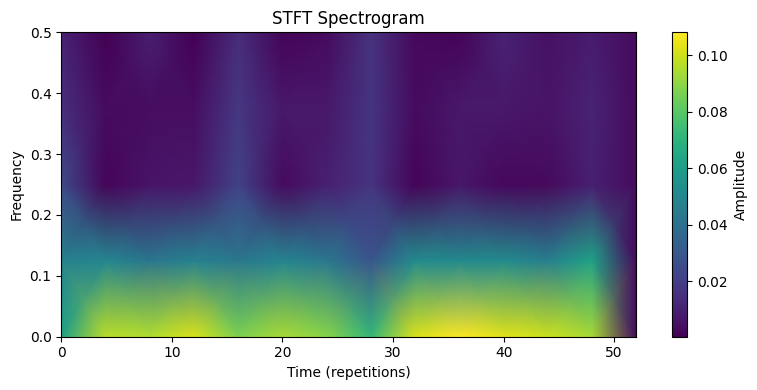

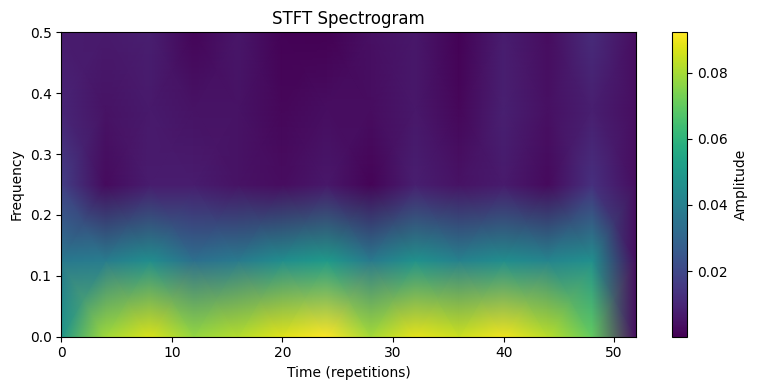


Different subject fidelity:
0.770062904891576


In [ ]:
import pandas as pd
import numpy as np
import scipy.signal
import matplotlib.pyplot as plt

class quantum:
    def __init__(self):
        # load the dataset directly; no parameter needed
        self.df = pd.read_csv("DSL-StrongPasswordData.csv")
        # these will be set by later methods
        self.sessions = None
        self.feature_matrix = None
        self.f = None
        self.t = None
        self.Zxx = None
        self.psi = None
        self.combined = None

    def check_columns(self):
        # inspect the dataset structure
        print("Columns:", self.df.columns.tolist())
        print("Shape:", self.df.shape)
        print("Unique sessions:", self.df['sessionIndex'].unique())

    def grp(self, subject):
        # filter rows for one subject only
        subject_data = self.df[self.df['subject'] == subject]
        # group those rows by session
        self.sessions = subject_data.groupby('sessionIndex')
        # print how many repetitions each session has
        for session_id, session_rows in self.sessions:
            print(f"Session {session_id}: {len(session_rows)} rows")

    def ext(self, session_id):
        # guard: grp must be called first
        if self.sessions is None:
            raise Exception("Call grp() before ext()")
        # get one session's rows
        one_session = self.sessions.get_group(session_id)
        # drop non-feature columns; keep only the 31 keystroke features
        non_feature_cols = ['subject', 'sessionIndex', 'rep']
        self.feature_matrix = one_session.drop(
            columns=non_feature_cols
        ).to_numpy()
        print("Feature matrix shape:", self.feature_matrix.shape)

    def stft_1c(self, feature_col=0, nperseg=8):
        if self.feature_matrix is None:
            raise Exception("Call ext() before stft_1c()")
        all_psi = []
        for col in range(self.feature_matrix.shape[1]):
            signal = self.feature_matrix[:, col]
            f, t, Zxx = scipy.signal.stft(signal, fs=1.0, nperseg=nperseg)
            ampl = np.abs(Zxx).flatten()
            all_psi.append(ampl)
            # store the last channel's 2D output just for plotting
            self.f = f
            self.t = t
            self.Zxx = Zxx
        self.combined = np.concatenate(all_psi)

    def encode(self):
        # guard: stft_1c must be called first
        if not hasattr(self, 'combined') or self.combined is None:
            raise Exception("Call stft_1c() before encode()")
        # compute L2 norm of the combined multi-channel vector
        norm = np.linalg.norm(self.combined)
        # guard against zero norm
        if norm < 1e-10:
            print("Warning: zero norm; cannot encode")
            return
        # divide by norm to get unit state vector
        self.psi = self.combined / norm
        print("State vector shape:", self.psi.shape)
        print("Norm check:", np.linalg.norm(self.psi))

    def get_state_vector(self, subject, session_id, feature_col=0, nperseg=8):
        # filter df for this specific subject and session
        session = self.df[
            (self.df['subject'] == subject) &
            (self.df['sessionIndex'] == session_id)
        ]
        # guard against empty result
        # edge case!!!!!!!!!!!!!!!!!!!!!
        if len(session) == 0:
            raise Exception(f"No data found for subject {subject} session {session_id}")
        # drop non-feature columns
        non_feature_cols = ['subject', 'sessionIndex', 'rep']
        feature_matrix = session.drop(columns=non_feature_cols).to_numpy()
        # extract signal from chosen feature column
        signal = feature_matrix[:, feature_col]
        # run STFT
        f, t, Zxx = scipy.signal.stft(signal, fs=1.0, nperseg=nperseg)
        # encode to state vector
        ampl = np.abs(Zxx)
        flat = ampl.flatten()
        norm = np.linalg.norm(flat)
        # guard against zero norm
        if norm < 1e-10:
            print("Warning: zero norm")
            return None
        return flat / norm

    def compute_fidelity(self, other):
        # guard: both objects must have psi set
        # edge case !!!!!!!!!!!!
        if self.psi is None:
            raise Exception("Call encode() on this object first")
        if other.psi is None:
            raise Exception("Call encode() on the other object first")
        # guard: both state vectors must be same length
        if len(self.psi) != len(other.psi):
            raise Exception("State vectors are different lengths; cannot compute fidelity")
        # inner product; squared absolute value
        inner = np.dot(self.psi, other.psi)
        F = np.abs(inner) ** 2
        # clip to [0,1] to handle floating point edge cases
        return np.clip(F, 0, 1)

    def plot_stft(self):
        if self.Zxx is None:
            raise Exception("Call stft_1c() before plot_stft()")
        plt.figure(figsize=(8, 4))
        plt.pcolormesh(self.t, self.f, np.abs(self.Zxx), shading='gouraud')
        plt.ylabel('Frequency')
        plt.xlabel('Time (repetitions)')
        plt.title('STFT Spectrogram')
        plt.colorbar(label='Amplitude')
        plt.tight_layout()
        plt.show()

class QuantumSession(quantum):
    def __init__(self, subject, session_id, feature_col=0, nperseg=8):
        # call parent init to load the dataframe
        super().__init__()
        # store identifying info
        self.subject = subject
        self.session_id = session_id
        # automatically run the full pipeline in order
        self.grp(subject)
        self.ext(session_id)
        self.stft_1c(feature_col=feature_col, nperseg=nperseg)
        self.encode()

# create two sessions for the same subject
s1 = QuantumSession('s002', 1)
s2 = QuantumSession('s002', 2)

print("\nSame subject fidelity:")
print(s1.compute_fidelity(s2))

# create a session for a different subject
s3 = QuantumSession('s003', 1)
s4 = QuantumSession('s004', 2)
s1.plot_stft()
s2.plot_stft()
s3.plot_stft()
s4.plot_stft()

print("\nDifferent subject fidelity:")
print(s1.compute_fidelity(s3))
print(s4.compute_fidelity(s3))